# Training and validation

In [1]:
import torch
from Utils import AnaliseGraficaVal, train, eval, fix_random_seed, predict
# Importe a classe que criamos anteriormente
from Datasets import Eucalyptus_openset_loader
from Modelos.ResNet18_32x32_backbone import ResNet18_32x32
from Modelos.AlexNet_backbone import Alexnet
from torchvision import transforms
from torchvision.models import AlexNet_Weights
import torch.nn as nn
import torch.optim as optim
from Utils.Nomes import NOMES
import gc
import os

# Configurações iniciais
fix_random_seed(42)
device = "cuda:0" if torch.cuda.is_available() else "cpu"

lr = 0.0001
epochs = 15
bs = 64
num_classes = 2
n_folds = 5
dataset= "dataset-1"

weights = AlexNet_Weights.IMAGENET1K_V1


# 2. Inicialização do Loader customizado
data_manager = Eucalyptus_openset_loader(bs=bs,dataset=dataset)
model_name = "AlexNet"
model_dir = f"/home/alexandreselani/Desktop/Eucalyptus/OpenSet/Models/{dataset}/"


In [2]:

for fold in range(n_folds):
    torch.cuda.empty_cache()
    
    gc.collect()

    grafico = AnaliseGraficaVal(f"{model_name}_fold_{fold}", "Eucalyptus open set", dir=f"/home/alexandreselani/Desktop/Eucalyptus/OpenSet/Graficos/{dataset}/")

    # 4. Modelo, Critério e Otimizador
    model = Alexnet(num_classes,weights=weights)
    model = model.to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    train_dataloader = data_manager.load_train(transform=weights.transforms(),fold=fold)
    
    val_dataloader = data_manager.load_kkc_val(transform=weights.transforms(),fold=fold)

    for epoch in range(epochs):
        model.train()
        train_loss, train_acc = train(train_dataloader, model, criterion, optimizer)
        
        model.eval()
        val_loss, val_acc = eval(val_dataloader, model, criterion)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | lr = {optimizer.param_groups[0]['lr']:.6f}")
        print(f"VALIDATION    | Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        grafico.addEpochVal(epoch, train_loss, train_acc, val_loss, val_acc)

    grafico.mostraGraficoVal()

    # 7. Salvamento
   
    
    os.makedirs(model_dir,exist_ok=True)
    torch.save(model.state_dict(), f"{model_dir}AlexNet_fold_{fold}.pt")
    print(f"Modelo salvo em {model_dir}")

    del model,optimizer,criterion,grafico,train_dataloader,val_dataloader

Epoch 1/15 | Train Loss: 0.6656 | Acc: 0.6225 | lr = 0.000100
VALIDATION    | Loss: 0.5014 | Acc: 1.0000
Epoch 2/15 | Train Loss: 0.3968 | Acc: 0.9803 | lr = 0.000100
VALIDATION    | Loss: 0.2432 | Acc: 1.0000
Epoch 3/15 | Train Loss: 0.1884 | Acc: 0.9944 | lr = 0.000100
VALIDATION    | Loss: 0.1080 | Acc: 1.0000
Epoch 4/15 | Train Loss: 0.0885 | Acc: 1.0000 | lr = 0.000100
VALIDATION    | Loss: 0.0558 | Acc: 1.0000
Epoch 5/15 | Train Loss: 0.0476 | Acc: 1.0000 | lr = 0.000100
VALIDATION    | Loss: 0.0349 | Acc: 1.0000
Epoch 6/15 | Train Loss: 0.0295 | Acc: 0.9972 | lr = 0.000100
VALIDATION    | Loss: 0.0248 | Acc: 1.0000
Epoch 7/15 | Train Loss: 0.0235 | Acc: 0.9944 | lr = 0.000100
VALIDATION    | Loss: 0.0189 | Acc: 1.0000
Epoch 8/15 | Train Loss: 0.0201 | Acc: 1.0000 | lr = 0.000100
VALIDATION    | Loss: 0.0150 | Acc: 1.0000
Epoch 9/15 | Train Loss: 0.0150 | Acc: 1.0000 | lr = 0.000100
VALIDATION    | Loss: 0.0124 | Acc: 1.0000
Epoch 10/15 | Train Loss: 0.0137 | Acc: 1.0000 | lr = 0

# Testing

In [3]:
# import numpy as np
# from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
# from Utils import AnaliseGraficaVal, train, eval, fix_random_seed, predict

# cm = np.zeros((num_classes,num_classes),dtype=int)

# for fold in range(n_folds):
#     model = Alexnet(num_classes=num_classes)
#     model.load_state_dict(torch.load(f"{model_dir}AlexNet_fold_{fold}.pt"))
#     model.to(device)
#     test_dataloader = data_manager.load_test(fold,transform=weights.transforms())

#     y_true = []
#     for _,y in test_dataloader:
#         y_true.append(y)

#     #print(y_true)
#     y_true = torch.concat(y_true)
#     y_pred = predict(test_dataloader,model)

    
#     y_true = y_true.cpu()
#     y_pred = y_pred.cpu()
    
#     cm += confusion_matrix(y_true,y_pred)


NameError: name 'ConfusionMatrixDisplay' is not defined

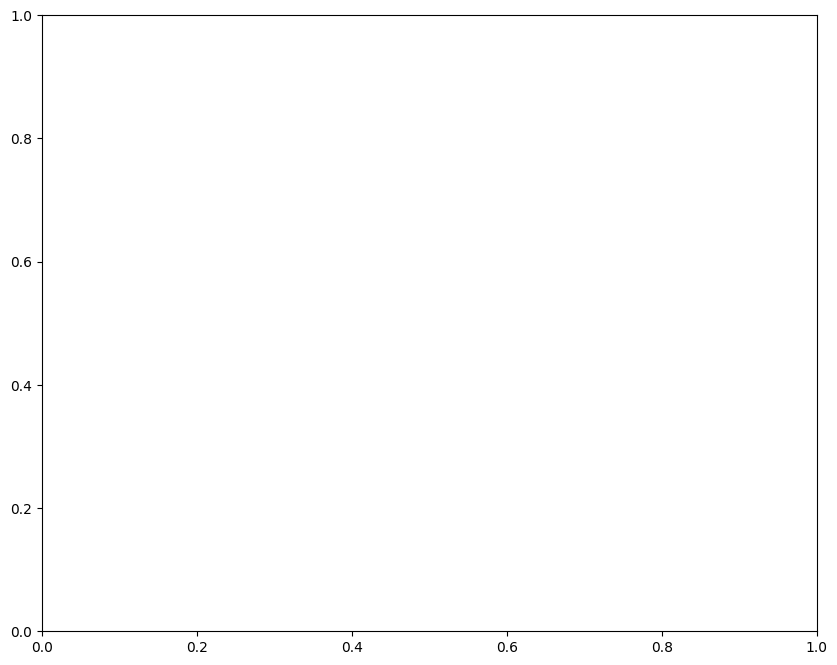

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[c for c in range(num_classes)])
disp.plot(ax=ax)
plt.title(f"Confusion matrix - {model_name}: {dataset}")
image_name = f"Confusion matrix - {model_name}: {dataset}.png"
plt.savefig(image_name, dpi=300, bbox_inches='tight')
plt.close(fig)